# A/B-тест алгоритма доставки

## Описание задачи

Представьте, что вы работаете аналитиком в крупной компании по доставке пиццы над приложением для курьеров.

У компании есть несколько ресторанов в разных частях города и большой штат курьеров. Однако существует проблема: к вечеру скорость доставки падает, так как часть курьеров заканчивает рабочий день и уходит домой, а количество заказов продолжает расти.

Это приводит к снижению эффективности доставки в момент пересмены.

---

## Новый алгоритм

Data Science команда разработала новый алгоритм, который позволяет курьерам планировать последние заказы перед окончанием смены так, чтобы маршрут доставки совпадал с маршрутом домой.

Идея заключается в том, чтобы курьеры доставляли последние заказы «по пути» домой.

---

## Проведение A/B-теста

Команда решила провести A/B-тест:

- одна часть курьеров использует старый алгоритм доставки;
- другая часть получает новую опцию «по пути домой» в приложении.

Задача аналитика — проанализировать результаты эксперимента и помочь бизнесу принять решение о внедрении новой функции для всех курьеров.

---

# Описание данных

| Поле | Описание |
|---|---|
| `order_id` | идентификатор заказа |
| `delivery_time` | время доставки заказа в минутах |
| `district` | район доставки |
| `experiment_group` | экспериментальная группа |

In [1]:
import pandas as pd

In [2]:
experiment = pd.read_csv('experiment_lesson_4.csv')

In [3]:
experiment.head()

,order_id,delivery_time,district,experiment_group
0,3159,44.0,Purlieus,control
1,10426,51.0,Purlieus,control
2,9155,46.0,Purlieus,control
3,10699,34.0,Purlieus,control
4,10061,43.0,Purlieus,control


In [4]:
experiment.shape

(20196, 4)

In [5]:
experiment.dtypes

order_id              int64
delivery_time       float64
district             object
experiment_group     object
dtype: object

In [6]:
import seaborn as sns

<Axes: xlabel='delivery_time', ylabel='Count'>

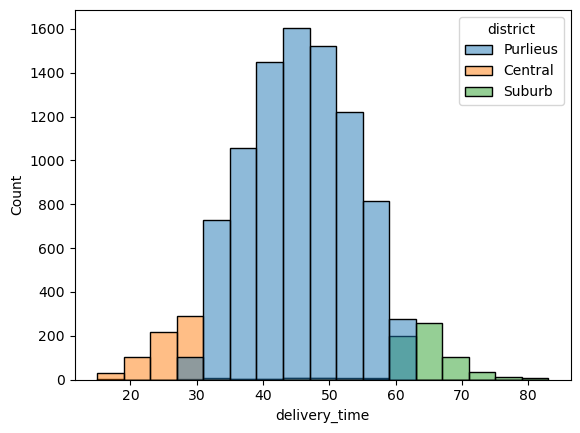

In [16]:
sns.histplot(data = experiment.query('experiment_group == "control" '), x = 'delivery_time', hue = 'district', bins=17)

<Axes: xlabel='delivery_time', ylabel='Count'>

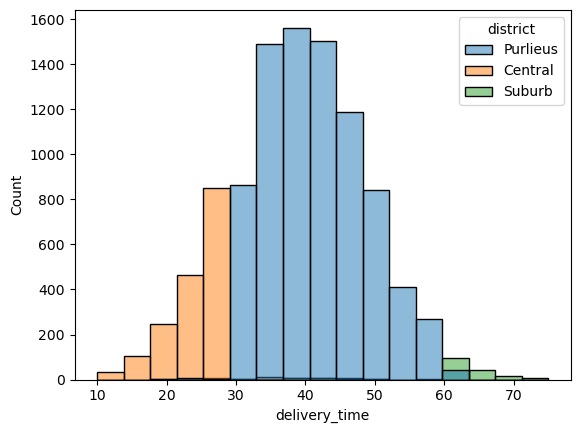

In [17]:
sns.histplot(data = experiment.query('experiment_group == "test" '), x = 'delivery_time', hue = 'district', bins=17)

## Задание 2
Посчитайте количество наблюдений в тестовой и контрольной группе. На сколько по модулю отличается количество наблюдений в тесте и контроле?

In [25]:
experiment.query('experiment_group == "test" ').order_id.count() - experiment.query('experiment_group == "control" ').order_id.count()

np.int64(12)

## Задание 3


Теперь давайте изучим наши распределения. Посмотрим на две вещи:

1. Распределены ли данные нормально

2. Стандартное отклонение в тесте и в контроле.

In [28]:
import scipy.stats as sts

In [29]:
sts.normaltest(experiment.query('experiment_group == "test" ').delivery_time)

NormaltestResult(statistic=np.float64(7.024157092641915), pvalue=np.float64(0.02983483685333173))

In [30]:
sts.normaltest(experiment.query('experiment_group == "control" ').delivery_time)

NormaltestResult(statistic=np.float64(0.25349755437872584), pvalue=np.float64(0.8809549607809654))

In [31]:
experiment.query('experiment_group == "test" ').delivery_time.std()

9.883308351129031

In [32]:
experiment.query('experiment_group == "control" ').delivery_time.std()

9.990016960247171

Вас могла смутить ненормальность распределения теста, полученная на прошлом шаге - однако если посмотреть на саму форму распределения, то оно не настолько сильно нарушает нормальность, чтобы об этом беспокоиться на таком размере выборки! Поэтому не переживаем 😎

И теперь пришло время сравнить средние в тесте и контроле!

In [33]:
test = experiment.query('experiment_group == "test" ').delivery_time
control = experiment.query('experiment_group == "control" ').delivery_time

In [34]:
sts.ttest_ind(test,control )

TtestResult(statistic=np.float64(-43.03582663183714), pvalue=np.float64(0.0), df=np.float64(20194.0))

На сколько процентов изменилось среднее время доставки в тестовой группе по сравнению с контрольной (округлите до сотых)? 

In [35]:
(test.mean()/control.mean() - 1)*100

np.float64(-13.354653121660808)

# Да, раскатываем новый алгоритм на всех, так как среднее время доставки статистически значимо изменилось. Среднее время доставки в тесте меньше, чем в контроле.